# Titanic Survival Prediction

## Objective

The objective of this project is to analyze Titanic passenger data and build a baseline machine learning model to predict whether a passenger survived.

## Problem Type

This is a binary classification problem because the target variable has two possible values:

- 0 = Did not survive
- 1 = Survived

## Dataset Description

The dataset contains passenger-level information such as passenger class, gender, age, fare, family members aboard, and embarkation port.

## Project Workflow

1. Load and understand the dataset
2. Check missing values and data types
3. Perform exploratory data analysis
4. Clean the data
5. Create useful features
6. Train baseline machine learning models
7. Evaluate and compare model performance
8. Summarize findings and next steps

In [5]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df = pd.read_csv("C:/Users/adhir/OneDrive/Desktop/Internship/data/train.csv")

In [7]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [8]:
df.shape

(891, 12)

In [9]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [11]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [12]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [13]:
df['Survived'].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

In [14]:
df['Survived'].value_counts(normalize=True) * 100

Survived
0    61.616162
1    38.383838
Name: proportion, dtype: float64

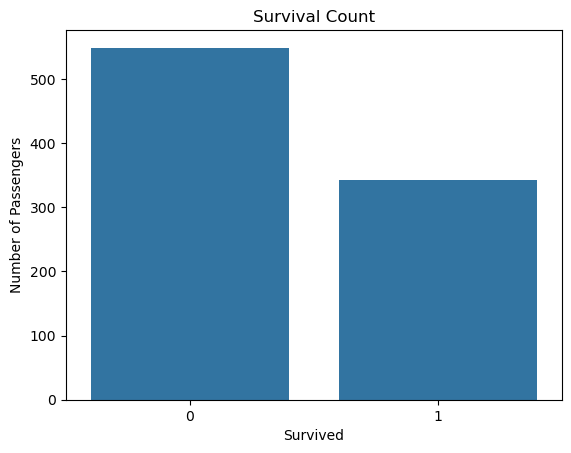

In [15]:
sns.countplot(data=df, x='Survived')
plt.title("Survival Count")
plt.xlabel("Survived")
plt.ylabel("Number of Passengers")
plt.show()

In [16]:
df.groupby('Sex')['Survived'].mean()

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

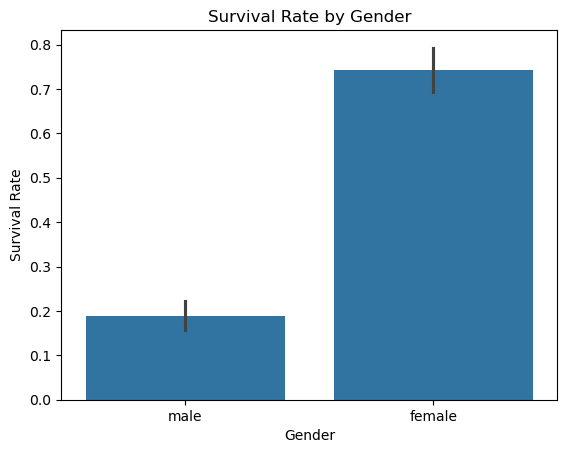

In [17]:
sns.barplot(data=df, x='Sex', y='Survived')
plt.title("Survival Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Survival Rate")
plt.show()

In [18]:
df.groupby('Pclass')['Survived'].mean()

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

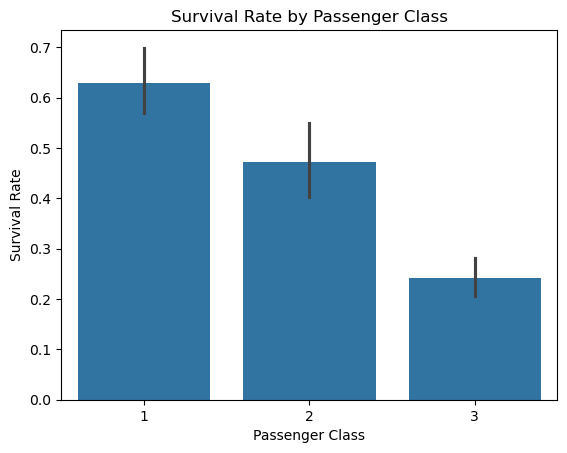

In [19]:
sns.barplot(data=df, x='Pclass', y='Survived')
plt.title("Survival Rate by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")
plt.show()

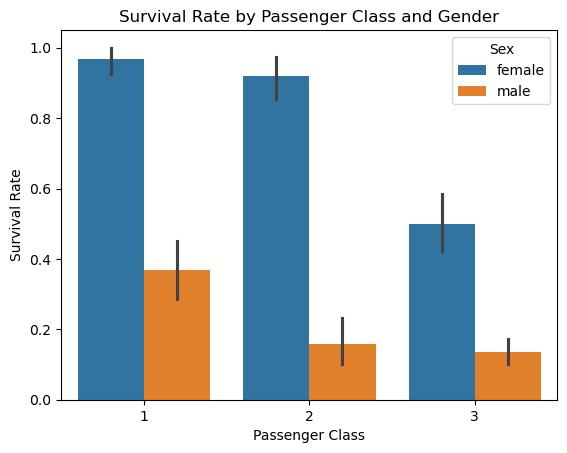

In [20]:
sns.barplot(data=df, x='Pclass', y='Survived', hue='Sex')
plt.title("Survival Rate by Passenger Class and Gender")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")
plt.show()

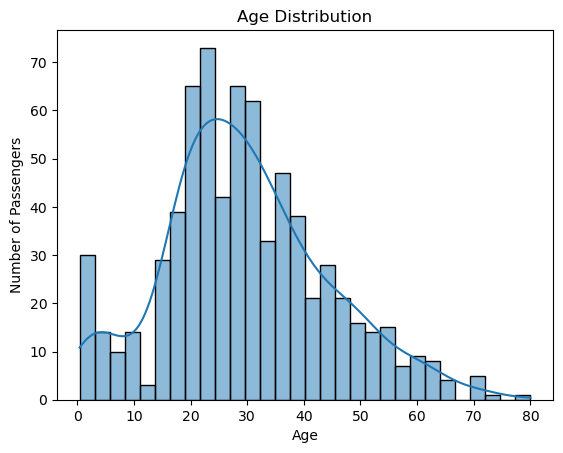

In [21]:
sns.histplot(df['Age'].dropna(), bins=30, kde=True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")
plt.show()

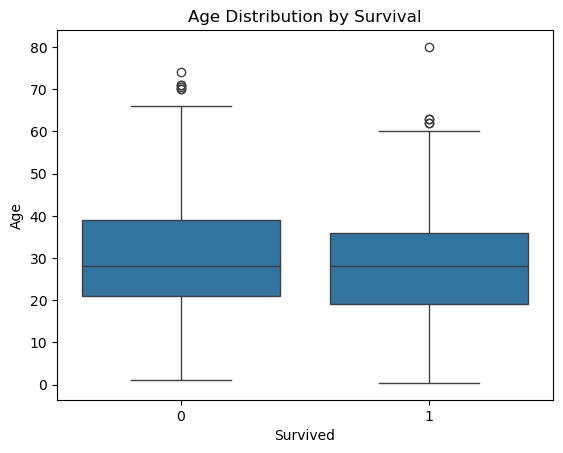

In [22]:
sns.boxplot(data=df, x='Survived', y='Age')
plt.title("Age Distribution by Survival")
plt.xlabel("Survived")
plt.ylabel("Age")
plt.show()

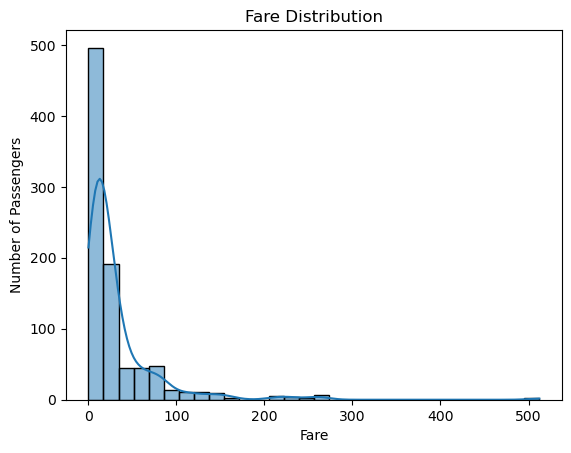

In [23]:
sns.histplot(df['Fare'], bins=30, kde=True)
plt.title("Fare Distribution")
plt.xlabel("Fare")
plt.ylabel("Number of Passengers")
plt.show()

In [24]:
df.groupby('Embarked')['Survived'].mean()

Embarked
C    0.553571
Q    0.389610
S    0.336957
Name: Survived, dtype: float64

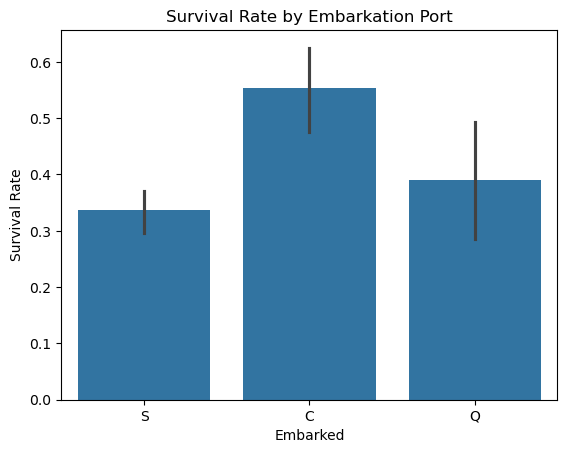

In [25]:
sns.barplot(data=df, x='Embarked', y='Survived')
plt.title("Survival Rate by Embarkation Port")
plt.xlabel("Embarked")
plt.ylabel("Survival Rate")
plt.show()

In [26]:
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

In [27]:
df.groupby('FamilySize')['Survived'].mean()

FamilySize
1     0.303538
2     0.552795
3     0.578431
4     0.724138
5     0.200000
6     0.136364
7     0.333333
8     0.000000
11    0.000000
Name: Survived, dtype: float64

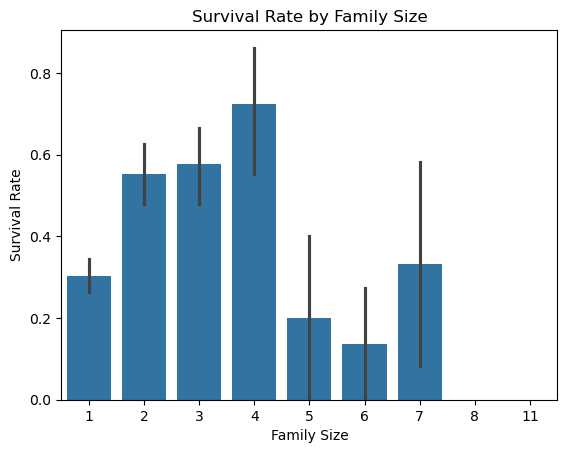

In [28]:
sns.barplot(data=df, x='FamilySize', y='Survived')
plt.title("Survival Rate by Family Size")
plt.xlabel("Family Size")
plt.ylabel("Survival Rate")
plt.show()

In [29]:
df_corr = df.copy()

In [30]:
df_corr['Sex'] = df_corr['Sex'].map({'male': 0, 'female': 1})

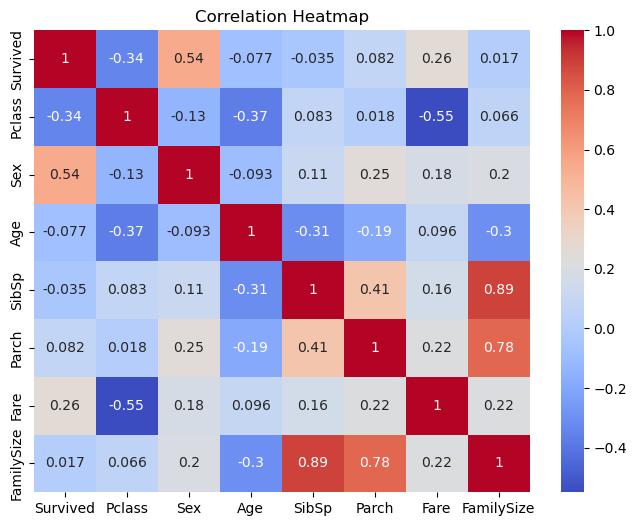

In [31]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    df_corr[['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize']].corr(),
    annot=True,
    cmap='coolwarm'
)
plt.title("Correlation Heatmap")
plt.show()

## EDA Summary

Based on the exploratory data analysis:

- Female passengers had a much higher survival rate than male passengers.
- First-class passengers had better survival chances than second- and third-class passengers.
- Gender and passenger class together show strong survival patterns.
- Fare is right-skewed and appears related to passenger class and survival.
- Age may be useful, especially if converted into age groups.
- Family size appears related to survival, so it may be useful to create family-based features.

These findings will guide the data cleaning and feature engineering steps before model training.

In [33]:
data = df.copy()

A copy of the original dataset was created before cleaning so that the raw data remains unchanged.

In [35]:
data.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
FamilySize       0
dtype: int64

Age, Cabin, and Embarked contain missing values. These need to be handled before training machine learning models.

In [37]:
data['Age'] = data['Age'].fillna(data['Age'].median())

Missing Age values were filled using the median age because median is less affected by outliers compared with the mean.

In [39]:
data['Embarked'] = data['Embarked'].fillna(data['Embarked'].mode()[0])

Missing Embarked values were filled using the mode because Embarked is a categorical variable.

In [41]:
data = data.drop(columns=['Cabin'])

Cabin was dropped because it contains many missing values. For a baseline model, using Cabin directly may add noise.

In [43]:
data.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
FamilySize     0
dtype: int64

After handling Age, Embarked, and Cabin, the dataset no longer contains missing values needed for the baseline model.

In [45]:
data['FamilySize'] = data['SibSp'] + data['Parch'] + 1

FamilySize was created by combining SibSp and Parch. The passenger themself is included by adding 1.

In [47]:
data['IsAlone'] = np.where(data['FamilySize'] == 1, 1, 0)

IsAlone was created to identify passengers traveling alone. This may help the model capture survival differences between solo passengers and passengers traveling with family.

In [49]:
data['Title'] = data['Name'].str.extract(' ([A-Za-z]+)', expand=False)

In [50]:
data['Title'].value_counts()

Title
Mr             502
Miss           179
Mrs            121
Master          40
Dr               7
Rev              6
y                4
Planke           3
Impe             3
Gordon           2
Col              2
Mlle             2
Major            2
Melkebeke        1
Jonkheer         1
Shawah           1
the              1
Velde            1
Capt             1
Messemaeker      1
Carlo            1
Ms               1
Mme              1
Steen            1
Mulder           1
Pelsmaeker       1
Walle            1
der              1
Billiard         1
Don              1
Cruyssen         1
Name: count, dtype: int64

Title was extracted from the passenger name because it may capture useful social and demographic information such as gender, age group, or social status.

In [52]:
data['Title'] = data['Title'].replace([
    'Lady', 'Countess', 'Capt', 'Col', 'Don', 'Dr', 
    'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'
], 'Rare')

data['Title'] = data['Title'].replace('Mlle', 'Miss')
data['Title'] = data['Title'].replace('Ms', 'Miss')
data['Title'] = data['Title'].replace('Mme', 'Mrs')

In [53]:
data['Title'].value_counts()

Title
Mr             502
Miss           182
Mrs            122
Master          40
Rare            20
y                4
Planke           3
Impe             3
Gordon           2
Billiard         1
der              1
Walle            1
Pelsmaeker       1
Mulder           1
Steen            1
Carlo            1
Messemaeker      1
Velde            1
the              1
Shawah           1
Melkebeke        1
Cruyssen         1
Name: count, dtype: int64

Rare titles were grouped together to reduce the number of categories. Similar titles such as Mlle, Ms, and Mme were mapped to more common titles.

In [55]:
data = data.drop(columns=['PassengerId', 'Name', 'Ticket'])

PassengerId, Name, and Ticket were dropped. PassengerId is only an identifier, Name was already used to extract Title, and Ticket has many unique values that may not be useful for a simple baseline model.

In [57]:
data = pd.get_dummies(data, columns=['Sex', 'Embarked', 'Title'], drop_first=True)

Categorical variables were converted into numeric dummy variables using one-hot encoding because machine learning models require numeric input.

In [59]:
data.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,FamilySize,IsAlone,Sex_male,Embarked_Q,...,Title_Pelsmaeker,Title_Planke,Title_Rare,Title_Shawah,Title_Steen,Title_Velde,Title_Walle,Title_der,Title_the,Title_y
0,0,3,22.0,1,0,7.2500,2,0,True,False,...,False,False,False,False,False,False,False,False,False,False
1,1,1,38.0,1,0,71.2833,2,0,False,False,...,False,False,False,False,False,False,False,False,False,False
2,1,3,26.0,0,0,7.9250,1,1,False,False,...,False,False,False,False,False,False,False,False,False,False
3,1,1,35.0,1,0,53.1000,2,0,False,False,...,False,False,False,False,False,False,False,False,False,False
4,0,3,35.0,0,0,8.0500,1,1,True,False,...,False,False,False,False,False,False,False,False,False,False


In [60]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 32 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Survived           891 non-null    int64  
 1   Pclass             891 non-null    int64  
 2   Age                891 non-null    float64
 3   SibSp              891 non-null    int64  
 4   Parch              891 non-null    int64  
 5   Fare               891 non-null    float64
 6   FamilySize         891 non-null    int64  
 7   IsAlone            891 non-null    int32  
 8   Sex_male           891 non-null    bool   
 9   Embarked_Q         891 non-null    bool   
 10  Embarked_S         891 non-null    bool   
 11  Title_Carlo        891 non-null    bool   
 12  Title_Cruyssen     891 non-null    bool   
 13  Title_Gordon       891 non-null    bool   
 14  Title_Impe         891 non-null    bool   
 15  Title_Master       891 non-null    bool   
 16  Title_Melkebeke    891 non

In [61]:
data.isnull().sum()

Survived             0
Pclass               0
Age                  0
SibSp                0
Parch                0
Fare                 0
FamilySize           0
IsAlone              0
Sex_male             0
Embarked_Q           0
Embarked_S           0
Title_Carlo          0
Title_Cruyssen       0
Title_Gordon         0
Title_Impe           0
Title_Master         0
Title_Melkebeke      0
Title_Messemaeker    0
Title_Miss           0
Title_Mr             0
Title_Mrs            0
Title_Mulder         0
Title_Pelsmaeker     0
Title_Planke         0
Title_Rare           0
Title_Shawah         0
Title_Steen          0
Title_Velde          0
Title_Walle          0
Title_der            0
Title_the            0
Title_y              0
dtype: int64

The cleaned dataset is now ready for machine learning. Missing values have been handled, useful features have been created, unnecessary columns have been removed, and categorical variables have been converted into numeric format.

In [63]:
data.columns

Index(['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize',
       'IsAlone', 'Sex_male', 'Embarked_Q', 'Embarked_S', 'Title_Carlo',
       'Title_Cruyssen', 'Title_Gordon', 'Title_Impe', 'Title_Master',
       'Title_Melkebeke', 'Title_Messemaeker', 'Title_Miss', 'Title_Mr',
       'Title_Mrs', 'Title_Mulder', 'Title_Pelsmaeker', 'Title_Planke',
       'Title_Rare', 'Title_Shawah', 'Title_Steen', 'Title_Velde',
       'Title_Walle', 'Title_der', 'Title_the', 'Title_y'],
      dtype='object')

## Data Cleaning and Feature Engineering Summary

In this step:

- Missing Age values were filled using the median.
- Missing Embarked values were filled using the mode.
- Cabin was dropped due to too many missing values.
- FamilySize was created using SibSp and Parch.
- IsAlone was created to identify passengers traveling alone.
- Title was extracted from passenger names.
- Rare titles were grouped together.
- Unnecessary columns were removed.
- Categorical variables were converted into numeric dummy variables.

The dataset is now ready for machine learning model training.

In [65]:
X = data.drop('Survived', axis=1)
y = data['Survived']

In [66]:
X = data.drop('Survived', axis=1)

In [67]:
y = data['Survived']

In [68]:
X.head()

,Pclass,Age,SibSp,Parch,Fare,FamilySize,IsAlone,Sex_male,Embarked_Q,Embarked_S,...,Title_Pelsmaeker,Title_Planke,Title_Rare,Title_Shawah,Title_Steen,Title_Velde,Title_Walle,Title_der,Title_the,Title_y
0,3,22.0,1,0,7.2500,2,0,True,False,True,...,False,False,False,False,False,False,False,False,False,False
1,1,38.0,1,0,71.2833,2,0,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,3,26.0,0,0,7.9250,1,1,False,False,True,...,False,False,False,False,False,False,False,False,False,False
3,1,35.0,1,0,53.1000,2,0,False,False,True,...,False,False,False,False,False,False,False,False,False,False
4,3,35.0,0,0,8.0500,1,1,True,False,True,...,False,False,False,False,False,False,False,False,False,False


In [69]:
y.head()

0    0
1    1
2    1
3    1
4    0
Name: Survived, dtype: int64

The dataset was separated into input features and target variable. `X` contains the passenger attributes used for prediction, while `y` contains the survival outcome.

In [71]:
from sklearn.model_selection import train_test_split

In [72]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [73]:
test_size=0.2

In [74]:
random_state=42

In [75]:
stratify=y

In [76]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((712, 31), (179, 31), (712,), (179,))

The dataset was split into training and testing sets. 80% of the data was used for training and 20% was reserved for testing. Stratification was used to preserve the class distribution of the target variable.

In [78]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [79]:
log_preds = log_model.predict(X_test)

In [80]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [81]:
log_accuracy = accuracy_score(y_test, log_preds)
log_precision = precision_score(y_test, log_preds)
log_recall = recall_score(y_test, log_preds)
log_f1 = f1_score(y_test, log_preds)

print("Logistic Regression Results")
print("Accuracy:", log_accuracy)
print("Precision:", log_precision)
print("Recall:", log_recall)
print("F1 Score:", log_f1)

Logistic Regression Results
Accuracy: 0.8491620111731844
Precision: 0.85
Recall: 0.7391304347826086
F1 Score: 0.7906976744186046


Logistic Regression was used as the first baseline model because it is simple, interpretable, and commonly used for binary classification problems.

In [83]:
from sklearn.tree import DecisionTreeClassifier

tree_model = DecisionTreeClassifier(random_state=42)

tree_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [84]:
tree_preds = tree_model.predict(X_test)

In [85]:
tree_accuracy = accuracy_score(y_test, tree_preds)
tree_precision = precision_score(y_test, tree_preds)
tree_recall = recall_score(y_test, tree_preds)
tree_f1 = f1_score(y_test, tree_preds)

print("Decision Tree Results")
print("Accuracy:", tree_accuracy)
print("Precision:", tree_precision)
print("Recall:", tree_recall)
print("F1 Score:", tree_f1)

Decision Tree Results
Accuracy: 0.7988826815642458
Precision: 0.746268656716418
Recall: 0.7246376811594203
F1 Score: 0.7352941176470589


A Decision Tree model was trained to compare performance with Logistic Regression. Decision Trees can capture non-linear relationships in the data but may overfit if not controlled.

In [87]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [88]:
rf_preds = rf_model.predict(X_test)

In [89]:
rf_accuracy = accuracy_score(y_test, rf_preds)
rf_precision = precision_score(y_test, rf_preds)
rf_recall = recall_score(y_test, rf_preds)
rf_f1 = f1_score(y_test, rf_preds)

print("Random Forest Results")
print("Accuracy:", rf_accuracy)
print("Precision:", rf_precision)
print("Recall:", rf_recall)
print("F1 Score:", rf_f1)

Random Forest Results
Accuracy: 0.8268156424581006
Precision: 0.7878787878787878
Recall: 0.7536231884057971
F1 Score: 0.7703703703703704


A Random Forest model was trained because it combines multiple decision trees and usually performs better than a single tree by reducing overfitting.

In [91]:
model_results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest'],
    'Accuracy': [log_accuracy, tree_accuracy, rf_accuracy],
    'Precision': [log_precision, tree_precision, rf_precision],
    'Recall': [log_recall, tree_recall, rf_recall],
    'F1 Score': [log_f1, tree_f1, rf_f1]
})

model_results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.849162,0.850000,0.739130,0.790698
1,Decision Tree,0.798883,0.746269,0.724638,0.735294
2,Random Forest,0.826816,0.787879,0.753623,0.770370


In [92]:
model_results.sort_values(by='F1 Score', ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.849162,0.850000,0.739130,0.790698
2,Random Forest,0.826816,0.787879,0.753623,0.770370
1,Decision Tree,0.798883,0.746269,0.724638,0.735294


The models were compared using Accuracy, Precision, Recall, and F1 Score. F1 Score is useful because it balances precision and recall, especially when the target classes are not perfectly balanced.

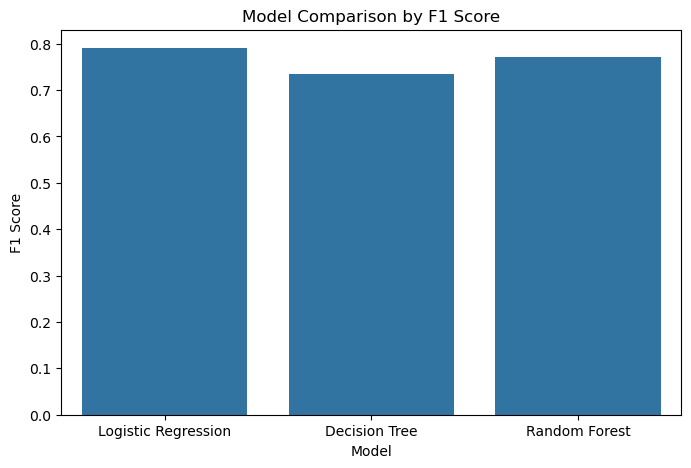

In [94]:
plt.figure(figsize=(8, 5))
sns.barplot(data=model_results, x='Model', y='F1 Score')
plt.title("Model Comparison by F1 Score")
plt.xlabel("Model")
plt.ylabel("F1 Score")
plt.xticks(rotation=0)
plt.show()

The model comparison chart shows which model performed best based on F1 Score. This helps select the strongest baseline model.

## Model Training Summary

Three baseline classification models were trained:

- Logistic Regression
- Decision Tree
- Random Forest

The models were evaluated using Accuracy, Precision, Recall, and F1 Score. Logistic Regression provides a simple baseline, Decision Tree captures non-linear patterns, and Random Forest improves stability by combining multiple trees.

Based on the comparison, the best-performing model can be selected for deeper evaluation using a confusion matrix and feature importance.

Logistic Regression performed best among the three baseline models, with the highest Accuracy and F1 Score. Random Forest performed second-best, while Decision Tree had the lowest performance. Based on these results, Logistic Regression is selected as the best baseline model for further evaluation.

In [98]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, log_preds)

cm

array([[101,   9],
       [ 18,  51]], dtype=int64)

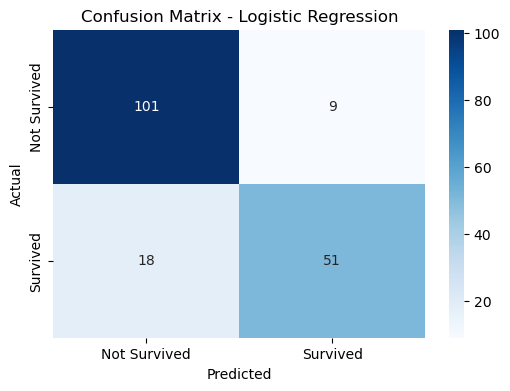

In [99]:
plt.figure(figsize=(6, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Not Survived', 'Survived'],
    yticklabels=['Not Survived', 'Survived']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

The confusion matrix shows how many passengers were correctly and incorrectly classified by the Logistic Regression model. This helps understand the types of errors the model is making, rather than only looking at overall accuracy.

In [101]:
from sklearn.metrics import classification_report

print(classification_report(y_test, log_preds))

              precision    recall  f1-score   support

           0       0.85      0.92      0.88       110
           1       0.85      0.74      0.79        69

    accuracy                           0.85       179
   macro avg       0.85      0.83      0.84       179
weighted avg       0.85      0.85      0.85       179



The classification report provides detailed performance metrics for both classes. This is useful because the model may perform differently for passengers who survived and passengers who did not survive.

In [103]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': log_model.coef_[0]
})

feature_importance['Absolute Coefficient'] = feature_importance['Coefficient'].abs()

feature_importance = feature_importance.sort_values(
    by='Absolute Coefficient',
    ascending=False
)

feature_importance

,Feature,Coefficient,Absolute Coefficient
14,Title_Master,1.520828,1.520828
7,Sex_male,-1.323431,1.323431
18,Title_Mr,-1.058328,1.058328
0,Pclass,-1.008107,1.008107
19,Title_Mrs,0.971187,0.971187
20,Title_Mulder,0.704264,0.704264
23,Title_Rare,-0.582789,0.582789
13,Title_Impe,-0.498410,0.498410
12,Title_Gordon,0.435994,0.435994
6,IsAlone,-0.394084,0.394084


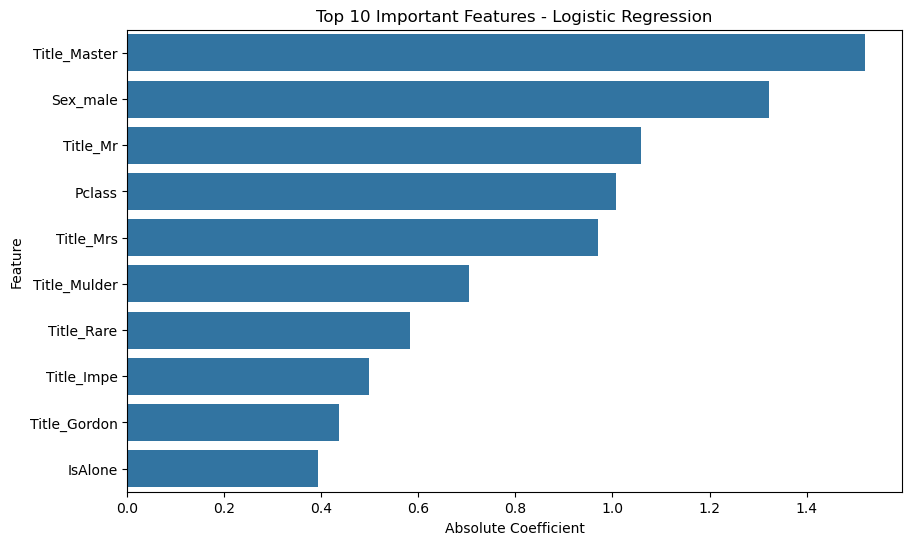

In [104]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance.head(10),
    x='Absolute Coefficient',
    y='Feature'
)

plt.title("Top 10 Important Features - Logistic Regression")
plt.xlabel("Absolute Coefficient")
plt.ylabel("Feature")
plt.show()

The feature importance chart shows which variables had the strongest influence on the Logistic Regression model. Features with larger absolute coefficients had a stronger impact on the prediction.

## Final Model Evaluation Summary

Three baseline models were trained and compared: Logistic Regression, Decision Tree, and Random Forest.

Logistic Regression performed best with:

- Accuracy: 0.849
- Precision: 0.850
- Recall: 0.739
- F1 Score: 0.791

Because Logistic Regression had the highest F1 Score and accuracy, it was selected as the best baseline model. The confusion matrix and classification report were used to better understand its performance.

This completes the Week 1 baseline ML model deliverable.

## Next Steps

To improve this project further, the following steparebe explored:

- Use cross-validation for more stable model evaluation
- Perform hyperparameter tuning
- Try additional feature engineering, such as AgeGroup and FareGroup
- Evaluate the model using R dataset

In [108]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(log_model, X, y, cv=5, scoring='f1')

print("Cross-validation F1 scores:", cv_scores)
print("Average CV F1 Score:", cv_scores.mean())

Cross-validation F1 scores: [0.78571429 0.74074074 0.75555556 0.7        0.8358209 ]
Average CV F1 Score: 0.7635662955065939


Cross-validation was used to evaluate the model across multiple data splits. This gives a more stable estimate of model performance compared with a single train-test split.

In [186]:
from sklearn.metrics import roc_auc_score, roc_curve

log_probs = log_model.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(y_test, log_probs)

print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 0.8782608695652174


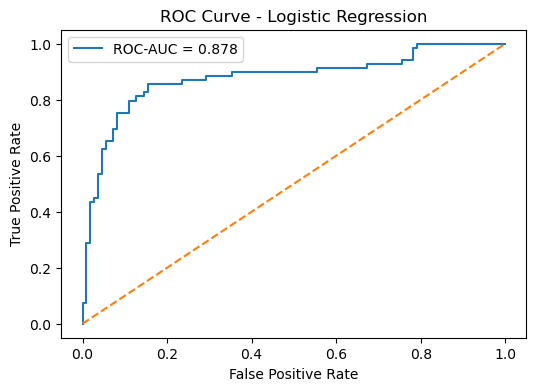

In [188]:
fpr, tpr, thresholds = roc_curve(y_test, log_probs)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f"ROC-AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.show()

ROC-AUC was used to evaluate how well the model separates survivors from non-survivors across different classification thresholds.